<a href="https://colab.research.google.com/github/vedikapatilvp07-crypto/blank-app/blob/main/AI_Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("AI Predictive Maintenance Project Started!")


AI Predictive Maintenance Project Started!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

print("Please select the file(s) you wish to upload:")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Please select the file(s) you wish to upload:


Saving Unconfirmed 576548.zip to Unconfirmed 576548.zip
User uploaded file "Unconfirmed 576548.zip" with length 140059 bytes


In [ ]:
import zipfile
import os

# Specify the path to the uploaded zip file
zip_file_path = '/content/Unconfirmed 576548.zip'

# Specify the directory where you want to extract the contents
extraction_path = '/content/unzipped_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

# List the contents of the extracted directory
print("\nContents of the unzipped directory:")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))


'/content/Unconfirmed 576548.zip' unzipped to '/content/unzipped_data'

Contents of the unzipped directory:
/content/unzipped_data/Unconfirmed 576548.crdownload


In [ ]:
from google.colab import files

print("Please select the file(s) you wish to upload:")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Please select the file(s) you wish to upload:


In [ ]:
import pandas as pd

df = pd.read_csv("predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (10000, 10)


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


In [ ]:
df["Target"].value_counts()

,count
Target,
0,9661
1,339


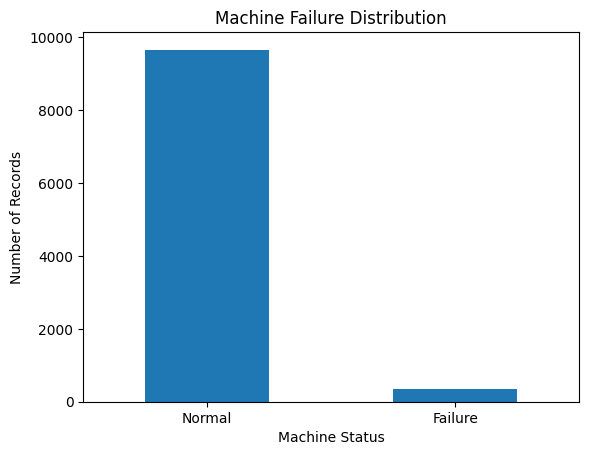

In [ ]:
import matplotlib.pyplot as plt

df["Target"].value_counts().plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["Normal", "Failure"], rotation=0)

plt.show()

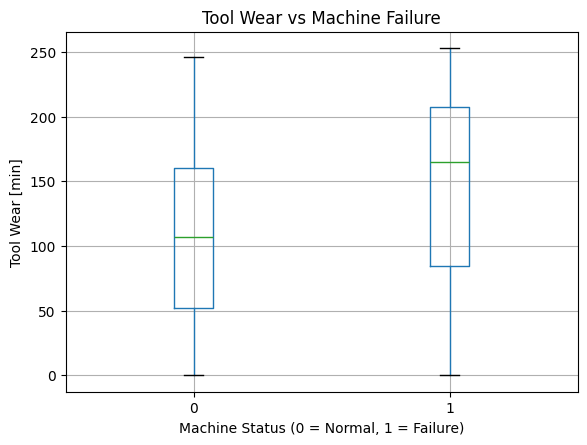

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column="Tool wear [min]", by="Target")

plt.title("Tool Wear vs Machine Failure")
plt.suptitle("")
plt.xlabel("Machine Status (0 = Normal, 1 = Failure)")
plt.ylabel("Tool Wear [min]")

plt.show()

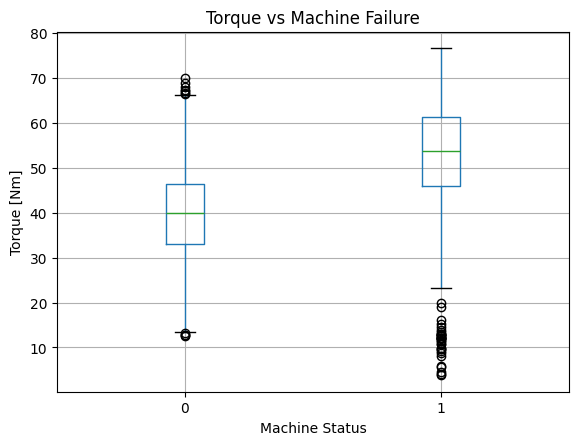

In [ ]:
df.boxplot(column="Torque [Nm]", by="Target")

plt.title("Torque vs Machine Failure")
plt.suptitle("")
plt.xlabel("Machine Status")
plt.ylabel("Torque [Nm]")

plt.show()

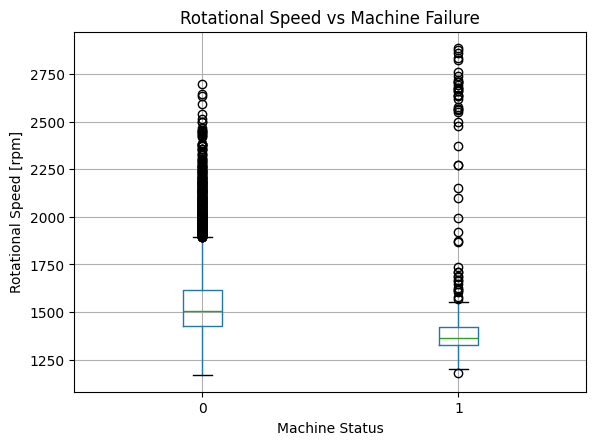

In [ ]:
df.boxplot(column="Rotational speed [rpm]", by="Target")

plt.title("Rotational Speed vs Machine Failure")
plt.suptitle("")
plt.xlabel("Machine Status")
plt.ylabel("Rotational Speed [rpm]")

plt.show()

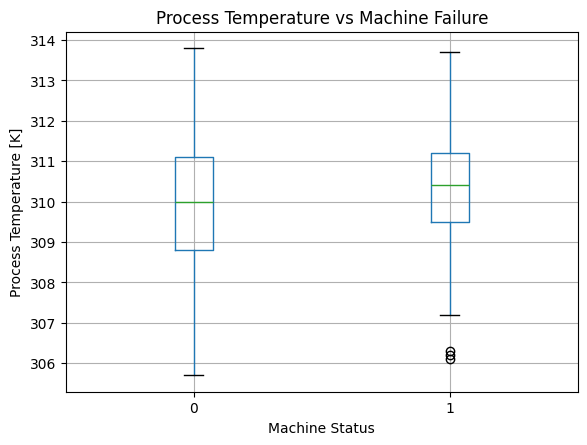

In [ ]:
df.boxplot(column="Process temperature [K]", by="Target")

plt.title("Process Temperature vs Machine Failure")
plt.suptitle("")
plt.xlabel("Machine Status")
plt.ylabel("Process Temperature [K]")

plt.show()

In [ ]:
X = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
]

y = df["Target"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  

Target:
0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64


In [ ]:
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 7)
Testing data: (2000, 7)


In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 7)
Testing data: (2000, 7)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.47      0.62        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
[[1929    3]
 [  36   32]]


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

print("First 20 failure probabilities:")
print(y_prob[:20])

First 20 failure probabilities:
[0.145 0.    0.06  0.005 0.075 0.    0.015 0.    0.    0.055 0.    0.01
 0.    0.    0.    0.    0.    0.195 0.    0.   ]


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

print("First 20 failure probabilities:")
print(y_prob[:20])

First 20 failure probabilities:
[0.145 0.    0.06  0.005 0.075 0.    0.015 0.    0.    0.055 0.    0.01
 0.    0.    0.    0.    0.    0.195 0.    0.   ]


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.30

y_pred_30 = (y_prob >= threshold).astype(int)

print("Classification Report - Threshold 30%:")
print(classification_report(y_test, y_pred_30))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_30))

Classification Report - Threshold 30%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.72      0.75        68

    accuracy                           0.98      2000
   macro avg       0.89      0.86      0.87      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
[[1919   13]
 [  19   49]]


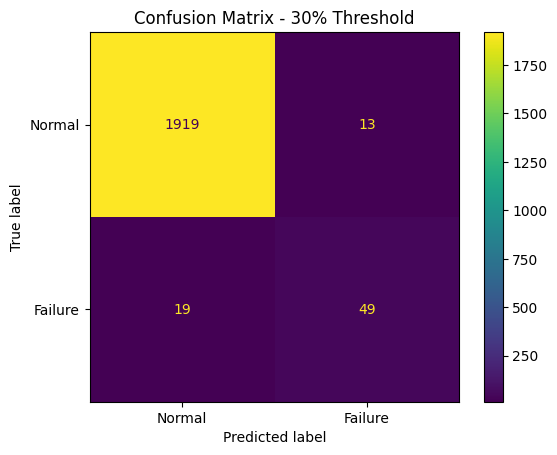

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_30,
    display_labels=["Normal", "Failure"]
)

plt.title("Confusion Matrix - 30% Threshold")
plt.show()

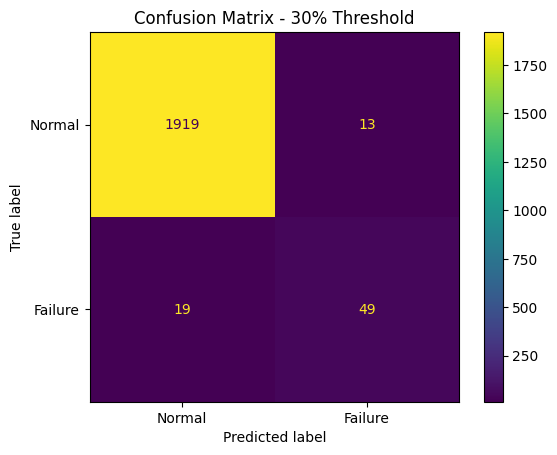

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_30,
    display_labels=["Normal", "Failure"]
)

plt.title("Confusion Matrix - 30% Threshold")
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

print("Threshold | Precision | Recall | F1-score")
print("------------------------------------------")

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"{threshold:9.0%} | "
        f"{precision:9.2f} | "
        f"{recall:6.2f} | "
        f"{f1:8.2f}"
    )

Threshold | Precision | Recall | F1-score
------------------------------------------
      10% |      0.41 |   0.87 |     0.56
      20% |      0.60 |   0.78 |     0.68
      30% |      0.79 |   0.72 |     0.75
      40% |      0.84 |   0.63 |     0.72
      50% |      0.91 |   0.47 |     0.62


In [ ]:
# Example of a new machine

new_machine = pd.DataFrame({
    "Type": ["M"],
    "Air temperature [K]": [300],
    "Process temperature [K]": [310],
    "Rotational speed [rpm]": [1500],
    "Torque [Nm]": [45],
    "Tool wear [min]": [100]
})

# Convert Type into the same format used during training
new_machine = pd.get_dummies(
    new_machine,
    columns=["Type"],
    drop_first=True
)

# Make sure the columns are exactly the same as training data
new_machine = new_machine.reindex(columns=X.columns, fill_value=False)

# Predict failure probability
failure_probability = model.predict_proba(new_machine)[0][1]

print("Failure Probability:", round(failure_probability * 100, 2), "%")

Failure Probability: 0.0 %


In [ ]:
new_machine = pd.DataFrame({
    "Type": ["M"],
    "Air temperature [K]": [305],
    "Process temperature [K]": [315],
    "Rotational speed [rpm]": [1400],
    "Torque [Nm]": [65],
    "Tool wear [min]": [200]
})

new_machine = pd.get_dummies(
    new_machine,
    columns=["Type"],
    drop_first=True
)

new_machine = new_machine.reindex(columns=X.columns, fill_value=False)

failure_probability = model.predict_proba(new_machine)[0][1]

print("Failure Probability:", round(failure_probability * 100, 2), "%")

Failure Probability: 39.5 %


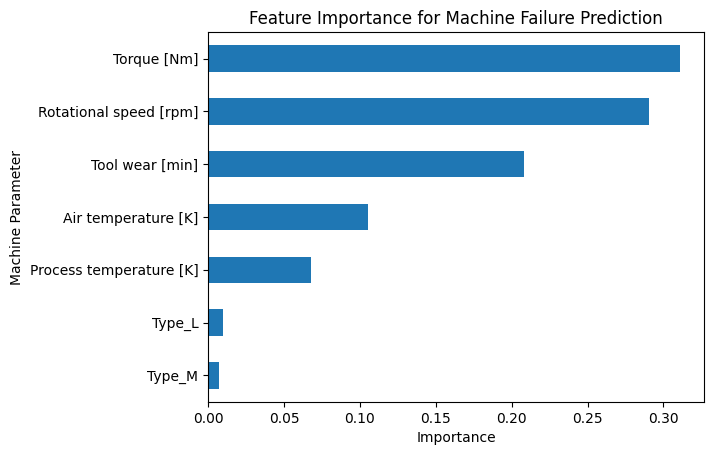

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importance.plot(kind="barh")

plt.title("Feature Importance for Machine Failure Prediction")
plt.xlabel("Importance")
plt.ylabel("Machine Parameter")

plt.show()

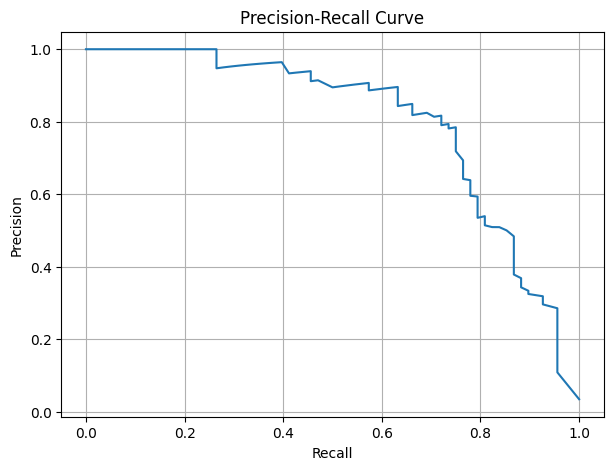

Average Precision Score: 0.797


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.show()

print("Average Precision Score:", round(ap, 3))

In [ ]:
print("Average Precision Score:", round(ap, 3))

Average Precision Score: 0.797


In [ ]:
import joblib

joblib.dump(model, "predictive_maintenance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import joblib

# Save the feature names used by the model
feature_names = list(X.columns)

joblib.dump(feature_names, "feature_names.pkl")

print("Feature information saved successfully!")
print(feature_names)

Feature information saved successfully!
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


In [ ]:
print(feature_names)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


In [ ]:
from google.colab import files

files.download("predictive_maintenance_model.pkl")
files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dir

<function dir>

In [ ]:
!streamlit run app.py &>/dev/null& # Run Streamlit in the background

from pyngrok import ngrok
import os

# Get the ngrok authentication token from environment variables or set it directly
# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok token if not set as an environment variable
# os.environ["NGROK_AUTH_TOKEN"] = "YOUR_NGROK_AUTHTOKEN"

# Terminate any existing ngrok tunnels
ngrok.kill()

# Authenticate ngrok (only needs to be done once)
# Make sure to replace "YOUR_NGROK_AUTHTOKEN" with your actual token
# If you already have it set up as an environment variable or authenticated previously, you can skip this.
# ngrok.set_auth_token("YOUR_NGROK_AUTHTOKEN")

# Open a tunnel to the Streamlit port (default is 8501)
public_url = ngrok.connect(addr='8501')
print(f"Streamlit App URL: {public_url}")

In [1]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 31.7 MB/s eta 0:00:00
